In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [26]:
%%time

import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

CPU times: user 3.51 ms, sys: 84 µs, total: 3.59 ms
Wall time: 3.41 ms


In [7]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=8000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
maxlen = 200
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

In [43]:
%%time

model = Sequential([
    Embedding(input_dim=8000, output_dim=128, input_length=maxlen),
    LSTM(128, dropout=0.5, recurrent_dropout=0.5),
    Dense(1, activation='sigmoid')
])

CPU times: user 9.27 ms, sys: 1.97 ms, total: 11.2 ms
Wall time: 8.34 ms


In [44]:
%%time

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

CPU times: user 4.02 ms, sys: 2.9 ms, total: 6.92 ms
Wall time: 5.75 ms


In [45]:
%%time

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

CPU times: user 13 µs, sys: 0 ns, total: 13 µs
Wall time: 17.2 µs


In [46]:
%%time

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 107s 166ms/step - accuracy: 0.6695 - loss: 0.6036 - val_accuracy: 0.8166 - val_loss: 0.4064
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 103s 164ms/step - accuracy: 0.8236 - loss: 0.3982 - val_accuracy: 0.8210 - val_loss: 0.4100
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 103s 165ms/step - accuracy: 0.8495 - loss: 0.3553 - val_accuracy: 0.8402 - val_loss: 0.3742
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 163ms/step - accuracy: 0.8680 - loss: 0.3152 - val_accuracy: 0.8512 - val_loss: 0.3719
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 163ms/step - accuracy: 0.8863 - loss: 0.2813 - val_accuracy: 0.8300 - val_loss: 0.4069
CPU times: user 30min 1s, sys: 1min 36s, total: 31min 38s
Wall time: 8min 36s


In [47]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.8481 - loss: 0.3746
Test Accuracy: 0.8496000170707703


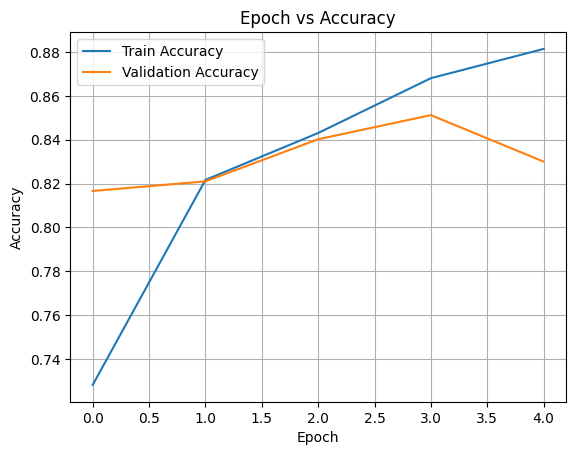

In [48]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Epoch vs Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

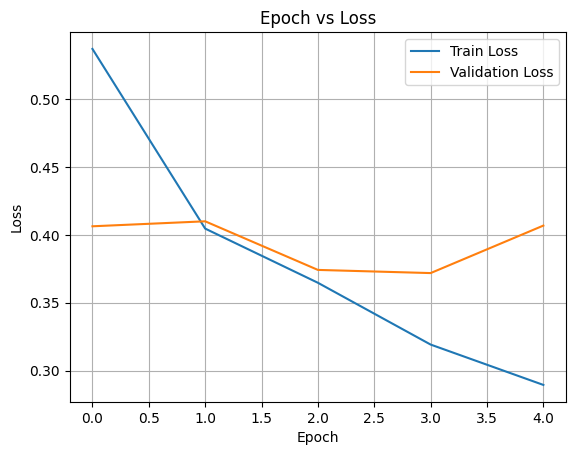

In [49]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Epoch vs Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()